## KNN implementation


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [3]:
df = pd.read_csv("./cleaned_property_data.csv")
df.head()

,Property Age,Carpet Area (sq.ft.),Super Buildup Rate (per sq.ft.),Built-Up Area (sq.ft.),Area as per Approved Plan (sq.ft.),Valuation Area (sq.ft.),Super Built-up Area (sq.ft.),Total Value (INR),No of Car Parks,Value of Car Park (INR),Final Value by Comparison Method (INR),Last Sale Price (per sq.ft.),Last to Last Sale Price (per sq.ft.),Last Sale Year,Last to Last Sale Year,garden,gym,lift,parking,playground,swimming_pool,garden.1,gym.1,lift.1,parking.1,playground.1,swimming_pool.1,Address_Area_encoded,Configuration_encoded,Condition_encoded,Landmark_Airport,Landmark_Hotel,Landmark_Mall,Landmark_Metro Station,Landmark_Park,Landmark_School,Trend_Ratio,Trend_Score
0,15,-1.351929,-1.113209,-1.354267,-1.365018,-1.354267,-1.408260,-0.996161,2,0.010401,-0.996070,-0.386878,-0.384093,2011,2011,1,0,0,0,0,0,0,0,0,0,1,0,31772.018928,1,1,False,False,True,False,False,False,1.151405,0.680708
1,6,-0.872300,-0.811877,-0.855542,-0.857951,-0.855542,-0.909855,-0.785320,2,0.010401,-0.785235,-0.526462,-0.521855,2020,2020,0,1,1,1,0,0,0,0,0,0,1,0,31772.018928,2,2,False,False,False,False,True,False,0.992883,0.491104
2,10,-0.848378,-0.833919,-0.839994,-0.851972,-0.839994,-0.826190,-0.787031,2,0.010401,-0.786946,-0.907596,-0.898012,2016,2016,0,0,0,0,0,1,1,0,0,0,0,0,30557.207420,2,3,False,False,False,False,True,False,1.110167,0.634329
3,8,0.390764,0.704999,0.377515,0.372642,0.377515,0.371417,0.470919,3,1.234081,0.477803,0.463728,0.255606,2020,2018,1,0,1,0,0,0,0,0,0,0,1,0,66625.574867,4,3,False,False,False,False,False,True,1.126486,0.653040
4,3,0.734040,0.476538,0.735114,0.739786,0.735114,0.788548,0.555970,1,-1.213278,0.549167,0.437721,0.429738,2023,2023,1,0,0,0,0,0,0,1,0,0,0,0,60796.945963,4,4,False,False,False,False,False,True,0.969054,0.461394


In [4]:
X = df.drop(columns=["Super Buildup Rate (per sq.ft.)"], errors="ignore")
y = df["Super Buildup Rate (per sq.ft.)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsRegressor()

In [7]:
y_pred = knn.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

Mean Squared Error: 0.0423
Mean Absolute Error: 0.1340
R^2 Score: 0.9537


## Visualizations
### 1. Regression fit vs actual

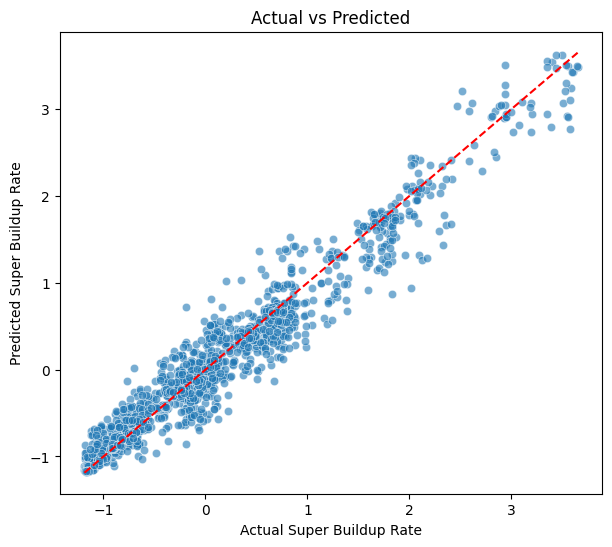

In [8]:
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45° line
plt.xlabel("Actual Super Buildup Rate")
plt.ylabel("Predicted Super Buildup Rate")
plt.title("Actual vs Predicted")
plt.show()

#### 2. Residual plots

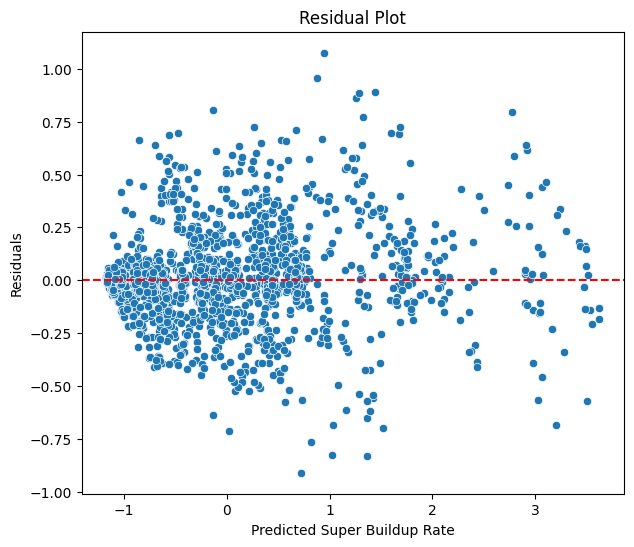

In [12]:
residuals = y_test - y_pred
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_pred, y=residuals, alpha=1)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Super Buildup Rate")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

#### 3. Distribution of error

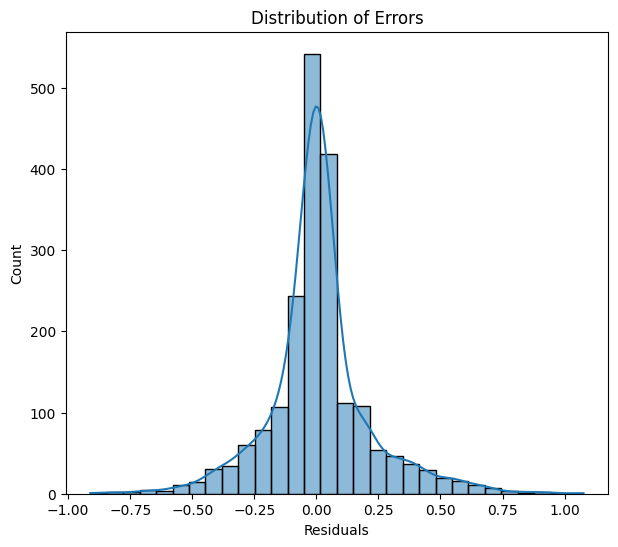

In [13]:
plt.figure(figsize=(7,6))
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel("Residuals")
plt.title("Distribution of Errors")
plt.show()

### Using grid search cv to obtain the best value of K
- hyperparameter tuning
- checking for k = 1 to 20
- scoring = 'negative mean sqaure error'

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': range(1, 21)}
grid = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

print(f"Best k: {grid.best_params_['n_neighbors']}")
print(f"Best CV MSE: {-grid.best_score_:.4f}")

Best k: 6
Best CV MSE: 0.0405


- `scoring = 'neg_mean_sqaured_error'` 
- This means the model is being evaluated using Mean Squared Error (MSE).
- But since scikit-learn expects higher = better scores, it stores MSE as a negative value.
- So:
        `score = (−)MSE`
- `-grid.best_score_` minus at starting makes it positive again

In [15]:
# Use the best k for prediction
best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R^2 Score with best k: {r2:.4f}")

R^2 Score with best k: 0.9552


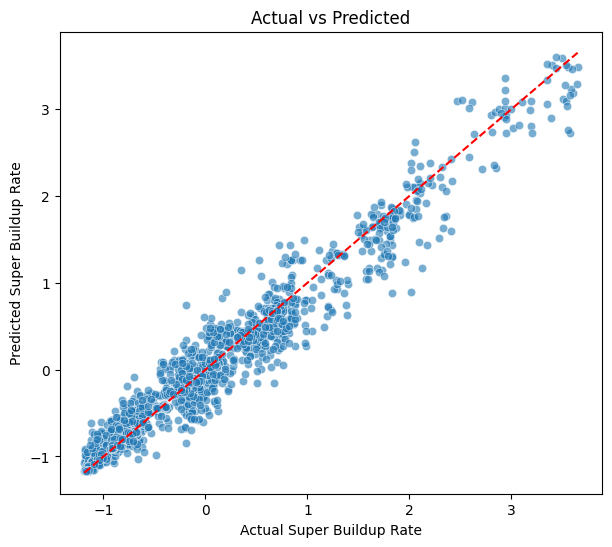

In [16]:
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45° line
plt.xlabel("Actual Super Buildup Rate")
plt.ylabel("Predicted Super Buildup Rate")
plt.title("Actual vs Predicted")
plt.show()

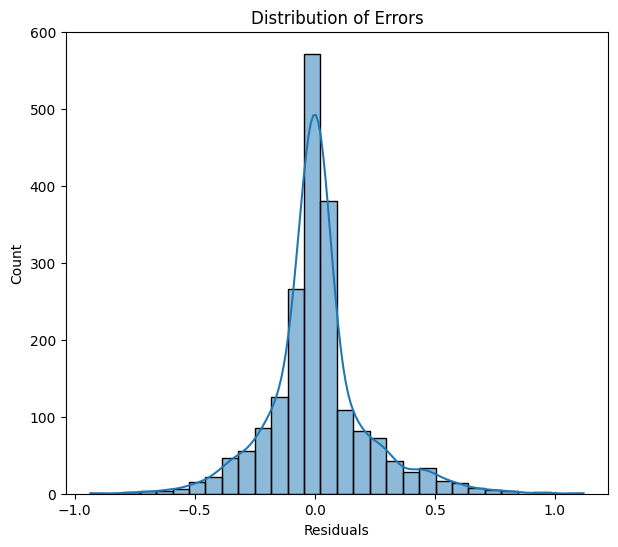

In [17]:
residuals = y_test - y_pred
plt.figure(figsize=(7,6))
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel("Residuals")
plt.title("Distribution of Errors")
plt.show()